In [219]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.gaussian import (
    Lens,
    Biprism,
    rectangular_input_wave,
    square_input_wave,
    run_to_end,
)

from temgym_core.plotting import plot_model, PlotParams

from temgym_core.utils import energy2wavelength
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper, evaluate_gaussians_for
from temgym_core.transfer_matrices import propagation_matrix, lens_matrix, biprism_matrix

import sympy as sp
jax.config.update("jax_enable_x64", True)

In [220]:
z1, z2, z_to_bi, z_to_im, biprism_def, M, f  = sp.symbols('z1 z2 z_{bi} z_{im} b_def M f')

biprism_mat = biprism_matrix(biprism_def)
prop_z1 = propagation_matrix(z1)
prop_to_biprism = propagation_matrix(z_to_bi)
lens_mat = lens_matrix(f)
prop_bi_to_im = propagation_matrix(z_to_im)

M_matrix = prop_bi_to_im @ biprism_mat @ prop_to_biprism @ lens_mat @ prop_z1 
M_matrix = M_matrix.applyfunc(sp.simplify)
display(M_matrix)

z2_im = (z1*f) / (z1 - f)


M_matrix_subs = M_matrix.subs({z_to_bi: z2 - z_to_im})
M_matrix_subs = M_matrix_subs.applyfunc(sp.simplify)
M_matrix_subs = M_matrix_subs.subs({z2: z2_im})
M_matrix_subs = M_matrix_subs.applyfunc(sp.simplify)
display(M_matrix_subs)

Matrix([
[1.0*(f - z_{bi} - z_{im})/f, 1.0*(f*(z_{bi} + z_{im}) + z1*(f - z_{bi} - z_{im}))/f, b_def*z_{im}],
[                     -1.0/f,                                         1.0 - 1.0*z1/f,        b_def],
[                          0,                                                      0,          1.0]])

Matrix([
[1.0*f/(f - z1),              0, b_def*z_{im}],
[        -1.0/f, 1.0 - 1.0*z1/f,        b_def],
[             0,              0,          1.0]])

In [ ]:
W = 1e-6
voltage = 200e3
wavelength = energy2wavelength(voltage)  # 300 keV

Nx = Ny = 2048
dx = W / Nx
dy = W / Ny

obj_mag = -80
obj_focal_length = 1e-2
z1, z2 = calculate_z1_and_z2_from_M_and_f(obj_mag, obj_focal_length)
z1, z2 = abs(z1), abs(z2)

fringe_spacing = 1e-7

biprism_z = z1 + z2 / 2
L = z2 - (z1 + obj_focal_length)
a = biprism_z - z1 + obj_focal_length
b = L - a
biprism_deflection = (wavelength * L) / (2 * fringe_spacing * a)
semi_angle = (W/2) / obj_focal_length
z_int = -semi_angle * a / (semi_angle - 2 * biprism_deflection)

input_grid = Detector(z=0.0, pixel_size=(dx, dy), shape=(Nx, Ny))
input_extent = input_grid.extent

output_grid = Detector(z=biprism_z + z_int, pixel_size=(dx * abs(obj_mag) / 2, dy * abs(obj_mag) / 2), shape=(Nx, Ny))
output_extent = output_grid.extent
xy = output_grid.coords_1d
x = xy[0]
y = xy[1]


k0 = 2 * jnp.pi / wavelength
num_rays = 200_000

x_max = W / 2

lens = Lens(z=z1, focal_length=obj_focal_length)
biprism = Biprism(z=biprism_z, strength=biprism_deflection, width=1e-12, sharpness=1e12)

In [222]:
rays_in = square_input_wave(aperture_length=W,
                            waist=5e-9,
                            num_rays=num_rays,
                            voltage=voltage,
                            amp=1.0,
                            phase=0.0,
                            z0=0.0)

In [223]:
E_in = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid)

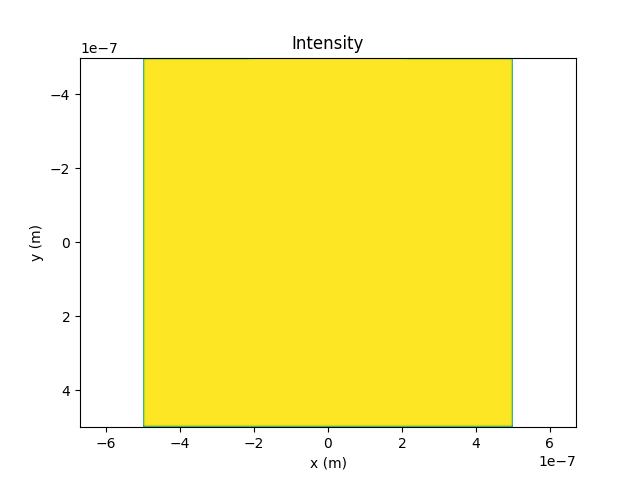

In [224]:
plt.figure()
plt.title('Intensity')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.imshow(np.abs(E_in), extent=input_extent)

In [225]:
run_to_end_vmapped = jax.vmap(run_to_end, in_axes=(0, None))

In [226]:
ray_out = run_to_end_vmapped(rays_in, [lens, biprism])

In [227]:
E_biprism = evaluate_gaussians_gpu_kernel_wrapper(ray_out, input_grid)

In [228]:
ray_out = run_to_end_vmapped(rays_in, [lens, biprism, output_grid])
E_out = evaluate_gaussians_gpu_kernel_wrapper(ray_out, output_grid)

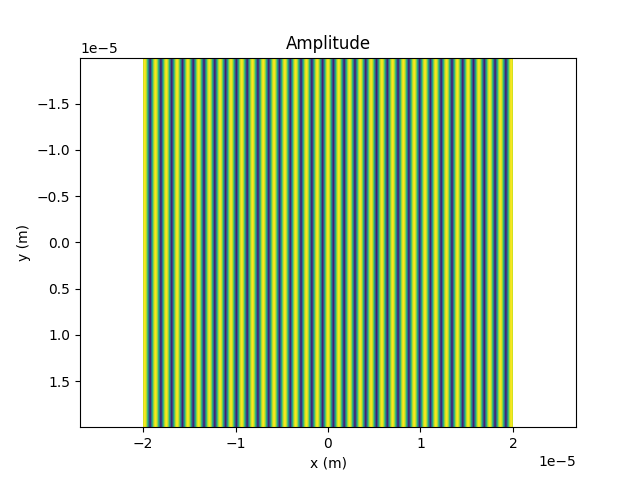

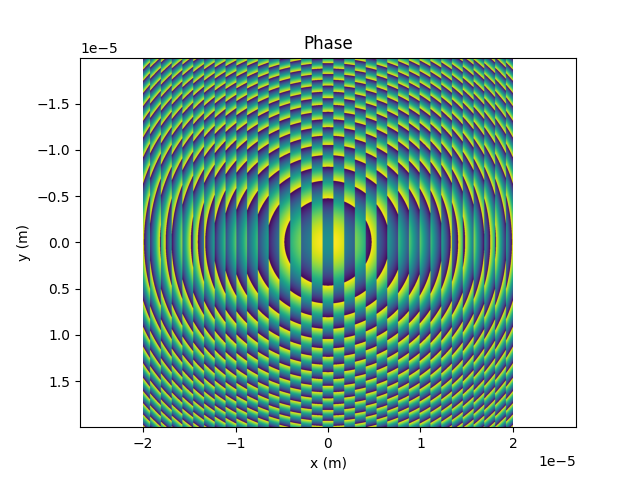

In [229]:
plt.figure()
plt.title('Amplitude')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.imshow(np.abs(E_out), extent=output_extent)
# plt.plot(ray_out.x, ray_out.y, 'r.', markersize=0.5)


plt.figure()
plt.title('Phase')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.imshow(np.angle(E_out), extent=output_extent)

In [230]:
# z1, z2 = calculate_z1_and_z2_from_M_and_f(obj_mag, obj_focal_length)
# z1, z2 = abs(z1), abs(z2)
# biprism_z = z1 + z2 / 5
# lens_z = z1
# lens_focal_length = 2.5e-3

# print(z1, z2, biprism_z, lens_z, lens_focal_length)
# a = (biprism_z - lens_z  + lens_focal_length)
# b = z1 + z2 - biprism_z
# L = a + b
# fringe_spacing = wavelength * (a + b) / (2 * a * biprism.strength)
# print(fringe_spacing)


In [231]:
# calculated_def = wavelength * (a + b) / (3e-9 * 2 * a)
# print(calculated_def)

Detected 35 peaks. Mean fringe spacing = 1.166e-06 m (std 9.137e-09)
Theoretical fringe spacing = 1.000e-07 m -> ratio measured/theory = 11.656


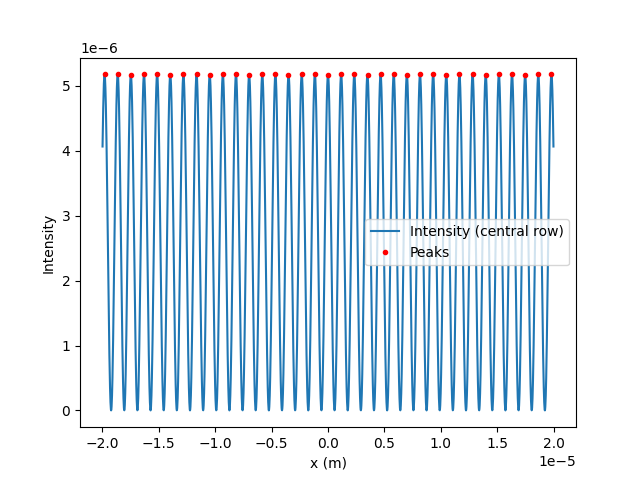

In [232]:
# measure fringe spacing from central row of E_out
intensity = np.abs(E_out[Nx//2, :])**2
x_np = np.array(x)
int_np = np.array(intensity)

# peak detection: local maxima above threshold (try 20% of max, then 5% if too few)
th = int_np.max() * 0.20
peaks = np.where((int_np[1:-1] > int_np[:-2]) & (int_np[1:-1] > int_np[2:]) & (int_np[1:-1] > th))[0] + 1
if len(peaks) < 2:
    th = int_np.max() * 0.05
    peaks = np.where((int_np[1:-1] > int_np[:-2]) & (int_np[1:-1] > int_np[2:]) & (int_np[1:-1] > th))[0] + 1

if len(peaks) >= 2:
    spacings = np.diff(x_np[peaks])
    mean_spacing = spacings.mean()
    std_spacing = spacings.std()
    print(f"Detected {len(peaks)} peaks. Mean fringe spacing = {mean_spacing:.3e} m (std {std_spacing:.3e})")
    # compare to theoretical value if available
    try:
        theo = float(np.array(fringe_spacing))
        print(f"Theoretical fringe spacing = {theo:.3e} m -> ratio measured/theory = {mean_spacing/theo:.3f}")
    except Exception:
        pass
else:
    print("Could not detect enough peaks to measure spacing.")

# plot with detected peaks
plt.figure()
plt.plot(x_np, int_np, label='Intensity (central row)')
if len(peaks) > 0:
    plt.plot(x_np[peaks], int_np[peaks], 'r.', label='Peaks')
plt.xlabel('x (m)')
plt.ylabel('Intensity')
plt.legend()




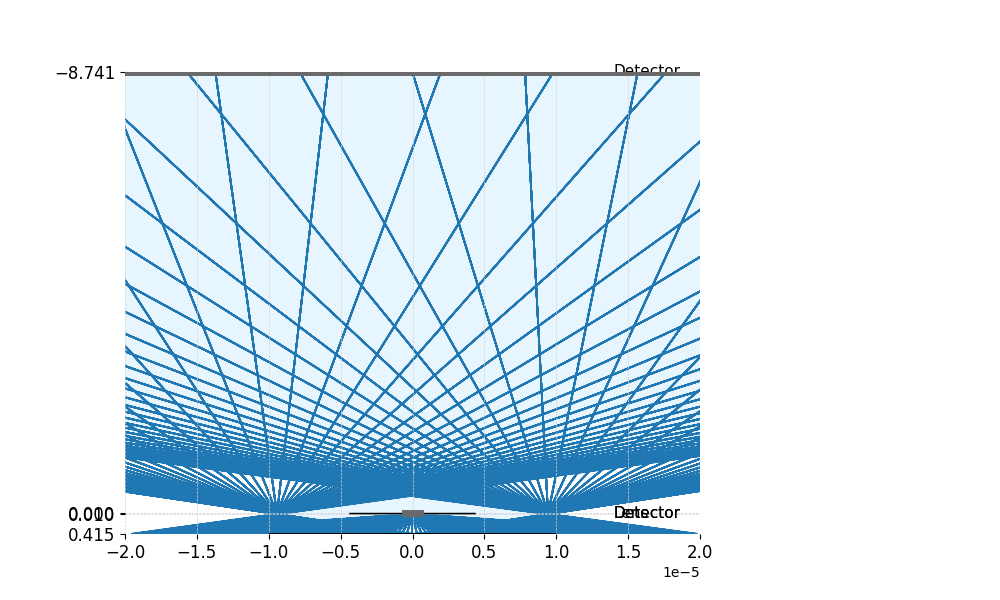

In [233]:
fig, ax = plot_model(
    components=[input_grid, lens, biprism, output_grid],
    rays=rays_in[0::100],
    plot_params=PlotParams(
        figsize=(10, 6),
    ),
)
